In [22]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


[*********************100%***********************]  10 of 10 completed


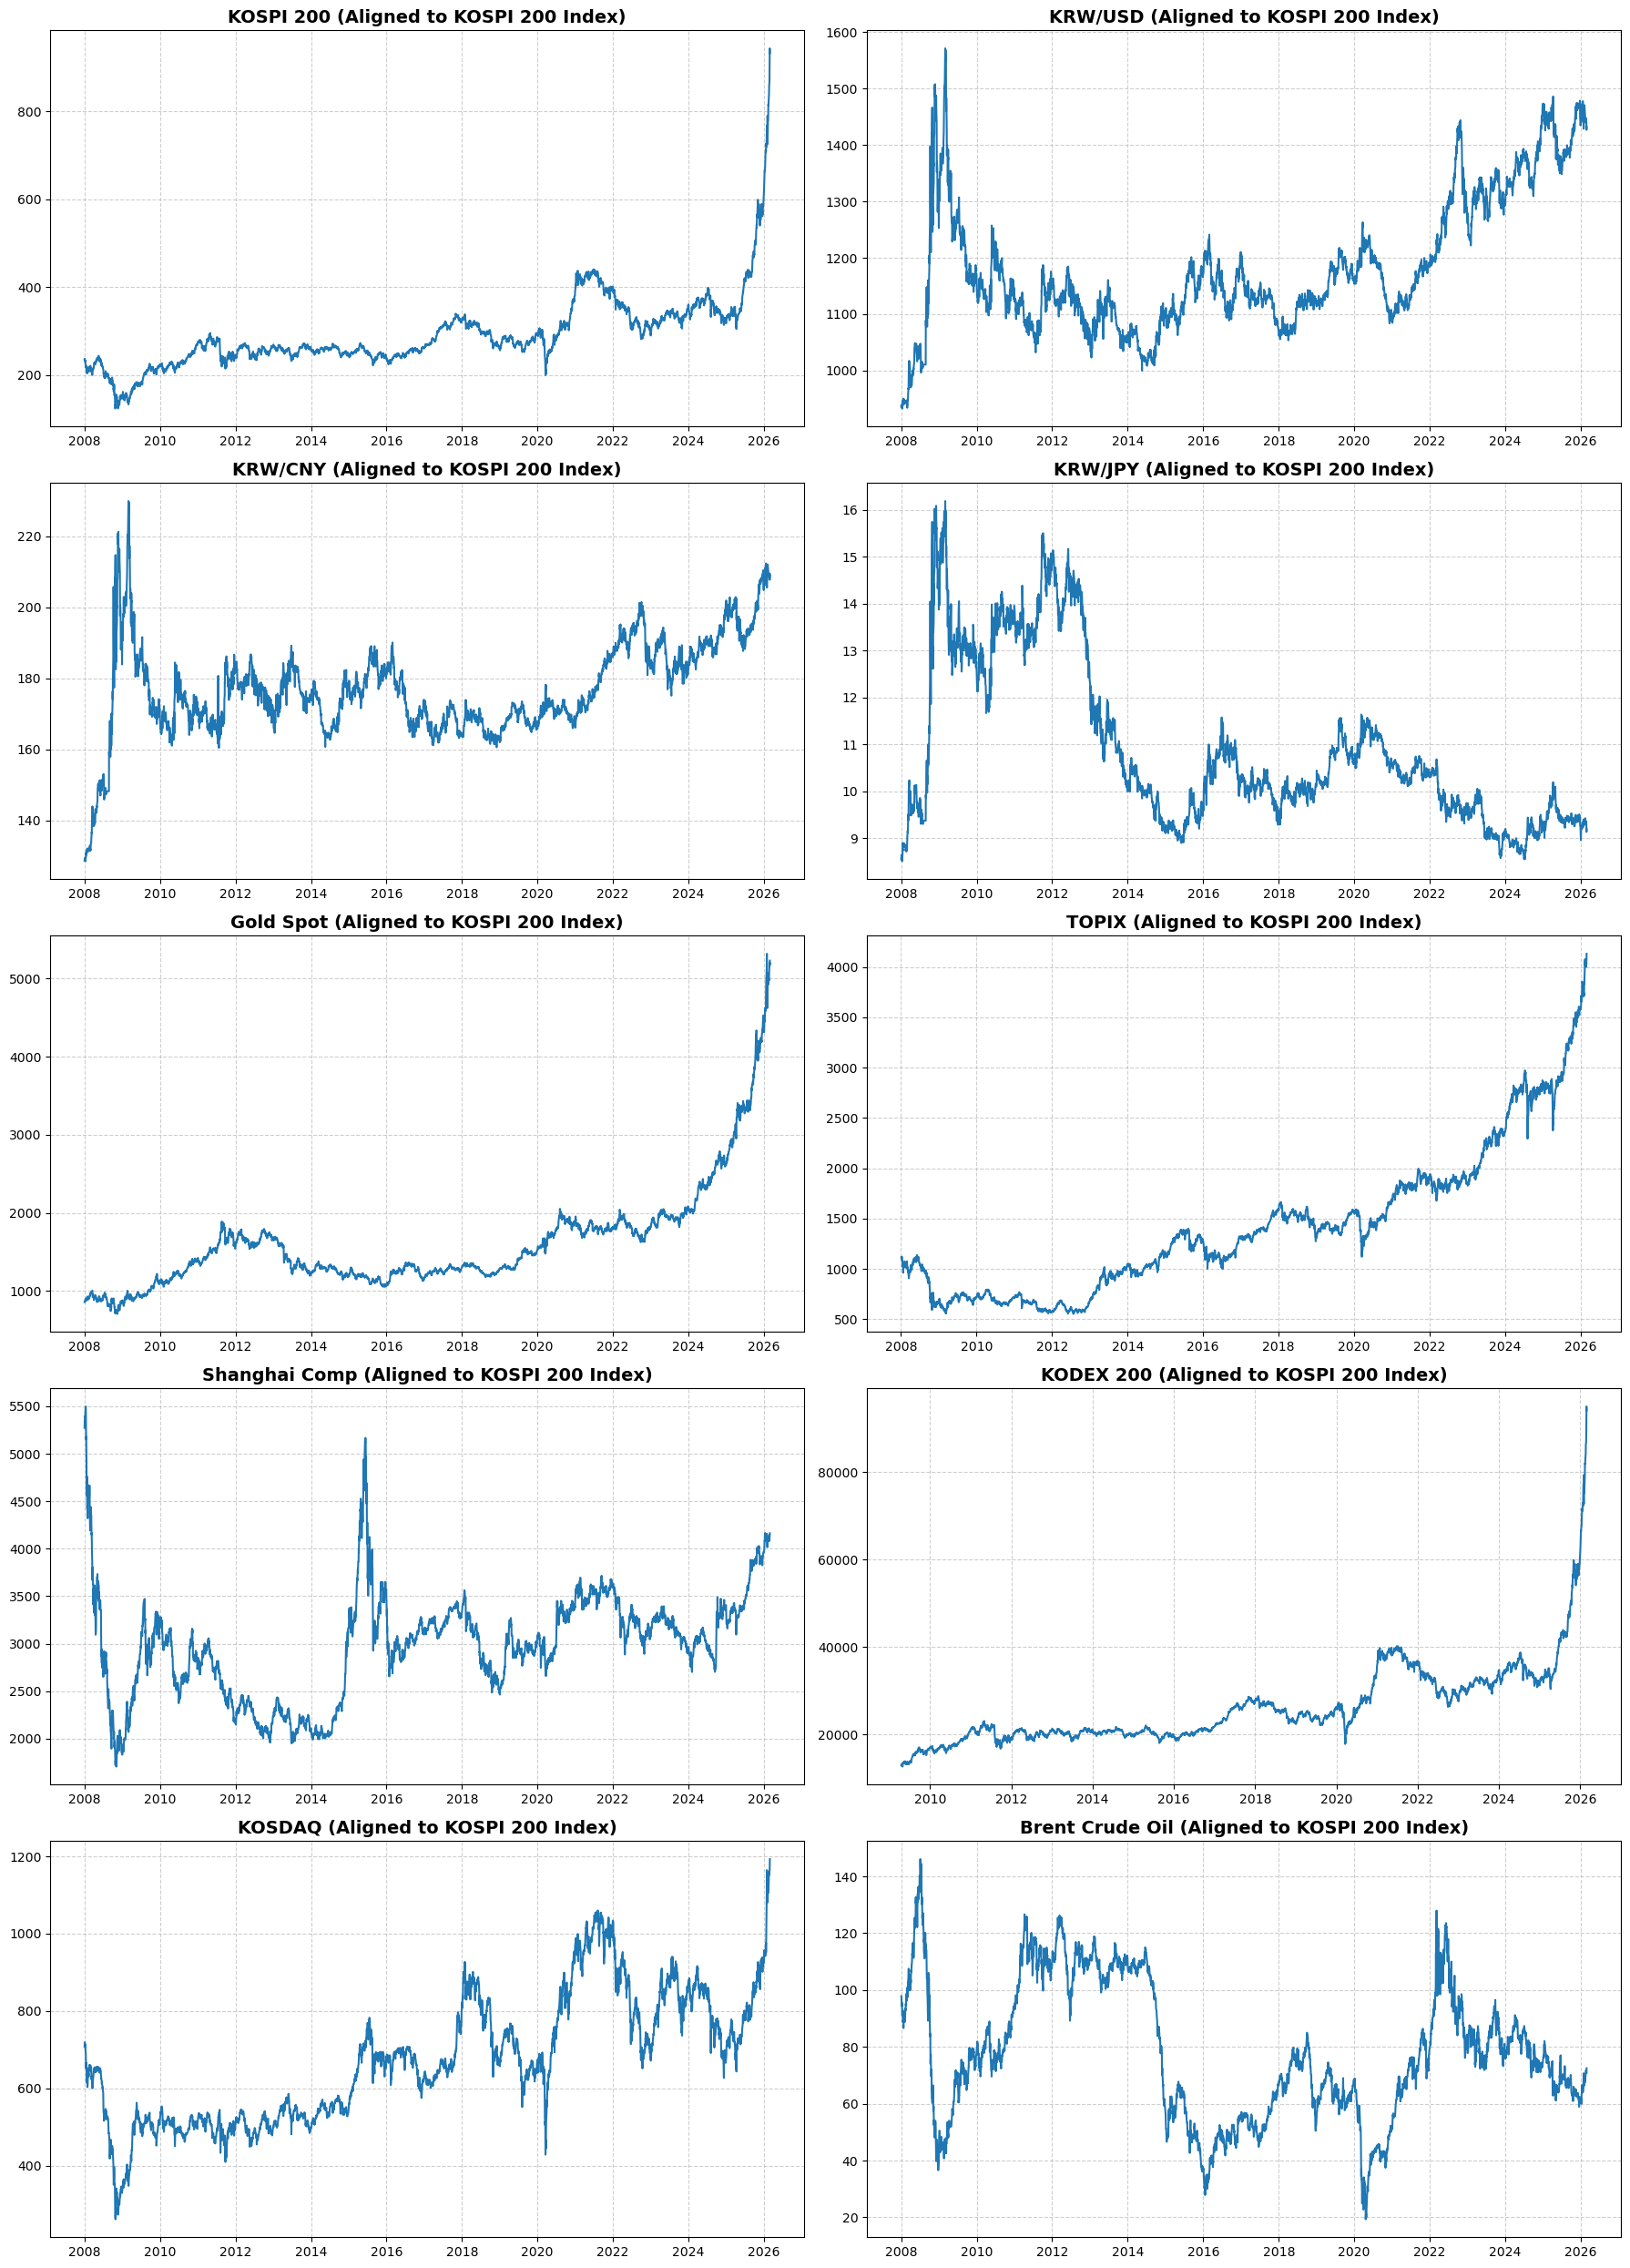

--- KOSPI 200 기준 정렬 검증 ---
전체 데이터 기간: 2008-01-02 ~ 2026-02-27
총 영업일 수: 4429일


Ticker,Shanghai Comp,KODEX 200,TOPIX,Brent Crude Oil,USD/CNY,Gold Spot,KRW/JPY,KRW/USD,KOSDAQ,KOSPI 200,KRW/CNY
Date,,,,,,,,,,,
2008-01-02,5272.813965,NaN,NaN,97.839996,7.2852,857.000000,8.5750,937.119995,707.119995,235.300003,128.633391
2008-01-03,5319.860840,NaN,NaN,97.599998,7.2629,866.400024,8.5379,935.150024,714.000000,234.669998,128.757114
2008-01-04,5361.574219,NaN,1111.187622,96.790001,7.2630,863.099976,8.6477,939.530029,719.250000,235.770004,129.358396
2008-01-07,5393.342773,NaN,1095.945435,94.389999,7.2578,859.599976,8.5970,939.270020,711.770020,231.000000,129.415251
2008-01-08,5386.530762,NaN,1104.136963,95.540001,7.2535,878.000000,8.6145,938.890015,709.309998,230.339996,129.439583


In [ ]:
# =========================================================
# 1) 분석 대상 자산과 야후 파이낸스 티커 매핑
# =========================================================
def get_tickers():
    return {
        'KOSPI 200': '^KS200',      # 기준 자산(영업일 캘린더 기준)
        'KRW/USD': 'KRW=X',         # 원/달러
        'USD/CNY': 'CNY=X',         # 달러/위안
        'KRW/JPY': 'JPYKRW=X',      # 원/엔
        'Gold Spot': 'GC=F',        # 금 선물
        'TOPIX': '1306.T',          # 일본 TOPIX ETF(대용)
        'Shanghai Comp': '000001.SS',
        'KODEX 200': '069500.KS',
        'KOSDAQ': '^KQ11',
        'Brent Crude Oil': 'BZ=F'   # 브렌트유 선물
    }


# =========================================================
# 2) 다운로드 + 정제 + 정렬
# =========================================================
def download_and_prepare_data(tickers, start='2008-01-01', end='2026-02-28'):
    raw_data = yf.download(list(tickers.values()), start=start, end=end)['Close'] #종가 사용

    name_mapping = {v: k for k, v in tickers.items()}
    data = raw_data.rename(columns=name_mapping)

    # KRW/CNY 교차환율 계산
    data['KRW/CNY'] = data['KRW/USD'] / data['USD/CNY']

    # KOSPI 200 영업일 기준 정렬 후 ffill
    reference_index = data['KOSPI 200'].dropna().index
    data = data.reindex(reference_index).ffill()

    return raw_data, name_mapping, data


# =========================================================
# 3) 전체 자산 시계열 시각화
# =========================================================
def plot_aligned_assets(data, save_path=None):
    plot_cols = [
        'KOSPI 200', 'KRW/USD', 'KRW/CNY', 'KRW/JPY', 'Gold Spot',
        'TOPIX', 'Shanghai Comp', 'KODEX 200', 'KOSDAQ', 'Brent Crude Oil'
    ]

    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 25))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        if col in data.columns:
            series = data[col].dropna()
            axes[i].plot(series.index, series.values, label=col, color='tab:blue')
            axes[i].set_title(f"{col} (Aligned to KOSPI 200 Index)", fontsize=14, fontweight='bold')
            axes[i].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig


# =========================================================
# 4) 기본 요약 출력
# =========================================================
def print_data_overview(data):
    print("--- KOSPI 200 기준 정렬 검증 ---")
    print(f"전체 데이터 기간: {data.index.min().date()} ~ {data.index.max().date()}")
    print(f"총 영업일 수: {len(data)}일")
    display(data.head())


# =========================================================
# 5) 결측치 검증
# =========================================================
def check_missing_values(data):
    final_na_counts = data.isna().sum()

    print("--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---")
    print(final_na_counts)

    print("\n--- 데이터 품질 검증 (시작일 및 샘플) ---")
    for col in data.columns:
        first_valid = data[col].first_valid_index()
        last_val = data[col].iloc[-1]
        remaining_na = data[col].loc[first_valid:].isna().sum()
        print(f"{col:15} | 시작일: {first_valid.date()} | 최근값: {last_val:10.2f} | 남은 NaN: {remaining_na}")

    print(f"\n전체 타임라인 행 수: {len(data)}")
    return final_na_counts



# =========================================================
# 8) CSV 저장
# =========================================================
def save_raw_csv(data, csv_path):
    data.to_csv(csv_path, index=True)


# =========================================================
# 실행 파이프라인
# =========================================================
tickers = get_tickers()
raw_data, name_mapping, data = download_and_prepare_data(tickers)
data_full = data.copy()


print_data_overview(data)

In [24]:
# 데이터 CSV 저장
save_raw_csv(data, r'C:\Users\dddhs\TS_RL_proj\data_file\raw_data\financial_data.csv')

In [25]:
# 정제된 데이터 결측치 검증
final_na_counts = check_missing_values(data)

--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---
Ticker
Shanghai Comp        0
KODEX 200          320
TOPIX                2
Brent Crude Oil      0
USD/CNY              0
Gold Spot            0
KRW/JPY              0
KRW/USD              0
KOSDAQ               0
KOSPI 200            0
KRW/CNY              0
dtype: int64

--- 데이터 품질 검증 (시작일 및 샘플) ---
Shanghai Comp   | 시작일: 2008-01-02 | 최근값:    4162.88 | 남은 NaN: 0
KODEX 200       | 시작일: 2009-04-17 | 최근값:   94120.00 | 남은 NaN: 0
TOPIX           | 시작일: 2008-01-04 | 최근값:    4131.00 | 남은 NaN: 0
Brent Crude Oil | 시작일: 2008-01-02 | 최근값:      72.48 | 남은 NaN: 0
USD/CNY         | 시작일: 2008-01-02 | 최근값:       6.84 | 남은 NaN: 0
Gold Spot       | 시작일: 2008-01-02 | 최근값:    5230.50 | 남은 NaN: 0
KRW/JPY         | 시작일: 2008-01-02 | 최근값:       9.19 | 남은 NaN: 0
KRW/USD         | 시작일: 2008-01-02 | 최근값:    1432.32 | 남은 NaN: 0
KOSDAQ          | 시작일: 2008-01-02 | 최근값:    1192.78 | 남은 NaN: 0
KOSPI 200       | 시작일: 2008-01-02 | 최근값:     933.34 | 남은 NaN: 0
KRW/CNY         | 시작일

In [28]:
# =========================================================
# 6) 기술적 피처(MA/EMA/RSI/BB) 생성 후 시작일 컷오프
# =========================================================
def add_technical_features(data_full, cutoff_date='2009-04-17', rsi_period=14, bb_period=20, bb_std_mult=2):
    data = data_full.copy()

    close = data['KOSPI 200']

    # MA/EMA
    data['KOSPI 200_MA5'] = close.rolling(window=5).mean()
    data['KOSPI 200_MA15'] = close.rolling(window=15).mean()
    data['KOSPI 200_EMA5'] = close.ewm(span=5, adjust=False).mean()
    data['KOSPI 200_EMA15'] = close.ewm(span=15, adjust=False).mean()

    # RSI (Wilder 방식)
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1 / rsi_period, adjust=False, min_periods=rsi_period).mean()
    avg_loss = loss.ewm(alpha=1 / rsi_period, adjust=False, min_periods=rsi_period).mean()
    rs = avg_gain / avg_loss
    data['KOSPI 200_RSI14'] = 100 - (100 / (1 + rs))

    # Bollinger Bands (중심선은 20일 SMA)
    bb_mid = close.rolling(window=bb_period).mean()
    bb_std = close.rolling(window=bb_period).std()
    data['KOSPI 200_BB_Upper'] = bb_mid + (bb_std_mult * bb_std)
    data['KOSPI 200_BB_Lower'] = bb_mid - (bb_std_mult * bb_std)

    data = data.loc[cutoff_date:].copy()
    return data


# =========================================================
# 7) KOSPI 200 + MA/EMA 시각화
# =========================================================
def plot_kospi_with_ma_ema(data):
    plt.figure(figsize=(14, 7))
    plt.plot(data.index, data['KOSPI 200'], label='KOSPI 200', color='black', linewidth=1.5)
    plt.plot(data.index, data['KOSPI 200_MA5'], label='MA 5', linestyle='--')
    plt.plot(data.index, data['KOSPI 200_MA15'], label='MA 15', linestyle='--')
    plt.plot(data.index, data['KOSPI 200_EMA5'], label='EMA 5')
    plt.plot(data.index, data['KOSPI 200_EMA15'], label='EMA 15')

    plt.title('KOSPI 200 with MA and EMA', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Index Level')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [29]:
# MA/EMA/RSI/BB 피처 생성 후 2009-04-17부터 사용
data = add_technical_features(data_full, cutoff_date='2009-04-17')

print(data[[
    'KOSPI 200',
    'KOSPI 200_MA5', 'KOSPI 200_MA15',
    'KOSPI 200_EMA5', 'KOSPI 200_EMA15',
    'KOSPI 200_RSI14',
    'KOSPI 200_BB_Upper', 'KOSPI 200_BB_Lower'
]].head(20))

print("\n[체크] 절단 후 기술적 피처 NaN 개수")
print(data[[
    'KOSPI 200_MA5', 'KOSPI 200_MA15',
    'KOSPI 200_EMA5', 'KOSPI 200_EMA15',
    'KOSPI 200_RSI14', 'KOSPI 200_BB_Upper', 'KOSPI 200_BB_Lower'
]].isna().sum())

Ticker       KOSPI 200  KOSPI 200_MA5  KOSPI 200_MA15  KOSPI 200_EMA5  \
Date                                                                    
2009-04-17  171.330002     171.598001      166.383999      170.855038   
2009-04-20  172.300003     171.720001      167.093332      171.336693   
2009-04-21  171.960007     171.706003      168.141999      171.544464   
2009-04-22  174.399994     172.344000      169.301333      172.496308   
2009-04-23  176.139999     173.226001      170.346665      173.710872   
2009-04-24  174.130005     173.786002      170.876666      173.850583   
2009-04-27  172.130005     173.752002      171.211333      173.277057   
2009-04-28  167.240005     172.808002      171.119334      171.264706   
2009-04-29  172.080002     172.344003      171.368668      171.536471   
2009-04-30  176.000000     172.316003      172.256668      173.024314   
2009-05-04  179.690002     173.428003      172.937335      175.246210   
2009-05-06  178.820007     174.766003      173.4126

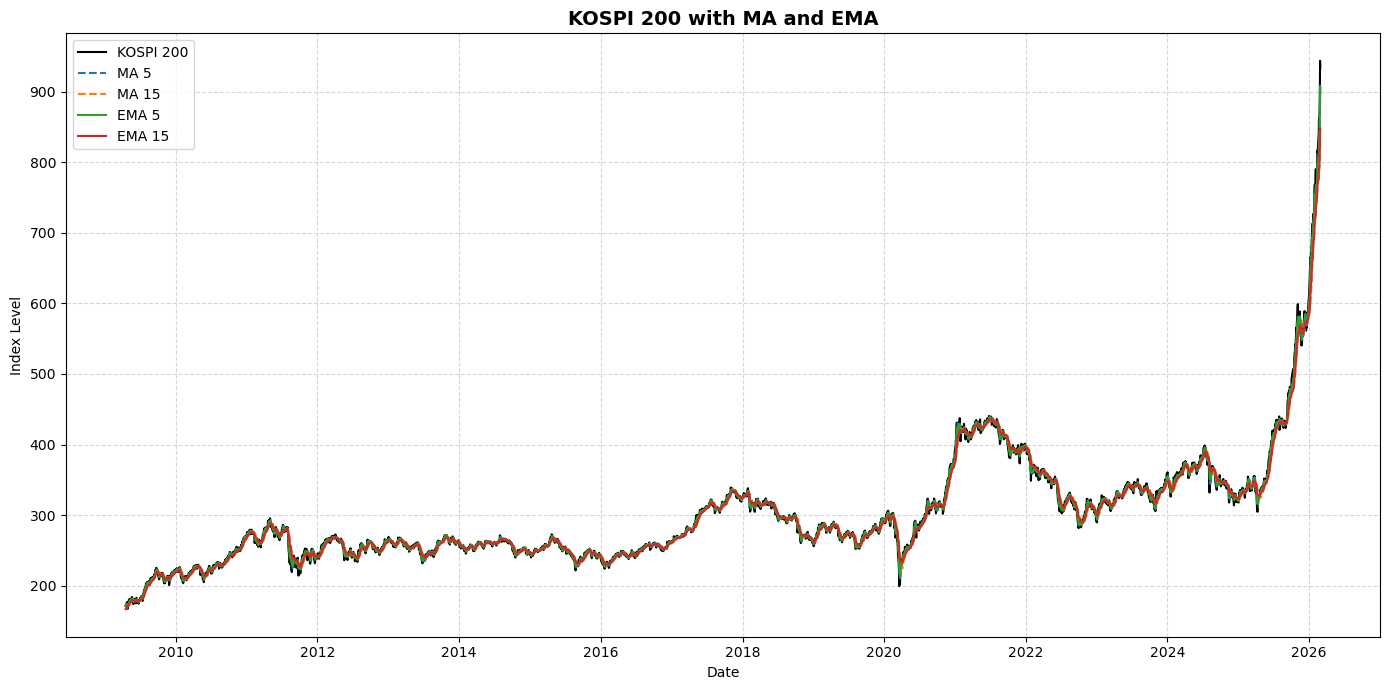

In [27]:
# KOSPI 200 + MA/EMA 시각화
plot_kospi_with_ma_ema(data)

In [30]:
# RSI/BB 생성 결과 최소 검증
check_cols = ['KOSPI 200_RSI14', 'KOSPI 200_BB_Upper', 'KOSPI 200_BB_Lower']

print('[생성 컬럼 존재 여부]')
print({c: (c in data.columns) for c in check_cols})

print('\n[NaN 개수]')
print(data[check_cols].isna().sum())

print('\n[최근 5행 샘플]')
print(data[check_cols].tail(5))

[생성 컬럼 존재 여부]
{'KOSPI 200_RSI14': True, 'KOSPI 200_BB_Upper': True, 'KOSPI 200_BB_Lower': True}

[NaN 개수]
Ticker
KOSPI 200_RSI14       0
KOSPI 200_BB_Upper    0
KOSPI 200_BB_Lower    0
dtype: int64

[최근 5행 샘플]
Ticker      KOSPI 200_RSI14  KOSPI 200_BB_Upper  KOSPI 200_BB_Lower
Date                                                               
2026-02-23        77.181817          864.910875          690.544124
2026-02-24        79.464268          881.754754          690.158247
2026-02-25        81.079369          899.901267          689.665737
2026-02-26        84.243667          924.448913          687.516096
2026-02-27        80.395862          943.050968          687.735042
